In [ ]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
from ipywidgets import interact, IntSlider, fixed
import tqdm 

n_cooldown = 13
date = '2026-06-15'


initialise_or_create_database_at(f"./{date}_SNSPD{n_cooldown}.db")
import snspd
params = snspd.snspd(f'snspd{n_cooldown}.yaml')

# Set up experiment
exp_name = f'SNSPD{n_cooldown}_{date}'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260622-34340-qcodes.log
Experiment loaded. Last ID no: 57


In [2]:
import importlib
importlib.reload(snspd)
params = snspd.snspd(f'snspd{n_cooldown}.yaml')

In [3]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)
yoko = station.load_instrument("yoko", revive_instance=True)
laser = station.load_instrument("laser", revive_instance=True)
MS = station.load_instrument("osc", revive_instance=True)
# pm100d = station.load_instrument("pm100d", revive_instance=True) 
pms120 = station.load_instrument("pms120", revive_instance=True)
tc = station.load_instrument("fridge", revive_instance=True)
p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

In [6]:
params.initialize_station()

In [18]:
import inspect
print(inspect.signature(params.critical_current))

(device, dmm=None, yoko=None, tc=None, station=None)


Bias arrangement for critical current sweep ID 1: 

|BNC | Yoko | DMM |
|---|---|---|
|9 | SIG | N/A |  
|10 | GND | N/A |
|11 | N/A | SIG |
|12 | N/A | GND |  


In [19]:
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc)

update station
Starting experimental run with id: 1. 
1
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current -8.5e-06
Starting current -8.75e-06
Starting curren

In [5]:
print(inspect.signature(params.ramp_yoko_current))

NameError: name 'inspect' is not defined

In [22]:
params.ramp_yoko_current(yoko, target=0, step=0.5e-6)
yoko.current(0)

Ramping to 0


In [30]:
load_by_id(1).metadata['device']

'R7C6'

In [9]:
params.args(params.critical_current)

(device, dmm=None, yoko=None, tc=None, unlatch=True, station=None)


In [14]:
params.critical_current(params.device_line_2, dmm, yoko, tc)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 2. 
2
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current -8

In [18]:
params.args(params.trace_vs_current)

(device, MS, dmm, yoko, trigger, v_scale, wait=120, currents=None, unlatch=True, station=None)


Sigh...the data set is missing current 13uA. Adding extra trigger value on the end. CHecked the SNSPD12-Line2-Count_Calibration.ipynb notebook and it is because the ID range  was set to range1 = np.arange(121, 173) which excludes ID 173 but it is ID 173 that contains the 13uA value. Regenerating data set to copy to config file. 

Note this run saved a dummy variable for p_att because it was not working at the time and was not necessary. 

In [31]:
trigger = [0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012,
       0.012, 0.012, 0.048, 0.048, 0.048, 0.048, 0.048, 0.048, 0.048,
       0.048, 0.048, 0.048, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102,
       0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102,
       0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102,
       0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102,0.102]
v_scale = 150e-3 # from SNSPD12.dB calibration measurements 
params.trace_vs_current(params.device_line_2, MS, dmm, yoko, trigger, v_scale)

Oscilloscope set for trace capture
list is trigger
single vscale value
update station
Ramping to 0
Unlatch wait time 60
Starting experimental run with id: 4. 
4


  0%|                                                                                           | 0/53 [00:00<?, ?it/s]

Check: trigger 0.012 v_scale 0.15
Oscilloscope set for trace capture
update station
Acquisition took 2.02 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


  2%|█▌                                                                                 | 1/53 [00:19<16:39, 19.23s/it]

Check: trigger 0.012 v_scale 0.15
Oscilloscope set for trace capture
update station
Acquisition took 2.03 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


...

Check: trigger 0.102 v_scale 0.15
Oscilloscope set for trace capture
update station
Acquisition took 2.01 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


 98%|████████████████████████████████████████████████████████████████████████████████▍ | 52/53 [13:20<00:17, 17.54s/it]

Check: trigger 0.102 v_scale 0.15
Oscilloscope set for trace capture
update station
Acquisition took 2.03 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


100%|██████████████████████████████████████████████████████████████████████████████████| 53/53 [13:39<00:00, 15.47s/it]


Ramping to 0
Unlatch wait time 60


Need to write function to generate the interactive plot with this. 

Bug in code meant that the triggers for all results were 0.012, and also vertical scale was saved as 1V. Can look at resolution of results to see what it actually was (25*smallest step). 

Dummy run to test the changes

In [36]:
params.args(params.trace_vs_current)

(device, MS, dmm, yoko, trigger, v_scale, wait=120, currents=None, unlatch=True, station=None)


In [37]:
trigger = [0.048, 0.102]
v_scale = 150e-3 # from SNSPD12.dB calibration measurements 
currents = [-10e-6, -11e-6]
params.trace_vs_current(params.device_line_2, MS, dmm, yoko, trigger, v_scale, currents=currents, unlatch=False)

Oscilloscope set for trace capture
list is trigger
single vscale value
update station
Ramping to -1e-05
Starting experimental run with id: 5. 
5


  0%|                                                                                            | 0/2 [00:00<?, ?it/s]

Oscilloscope set for trace capture
update station
Acquisition took 2.02 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;640.00E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


 50%|██████████████████████████████████████████                                          | 1/2 [00:09<00:09,  9.25s/it]

Oscilloscope set for trace capture
update station
Acquisition took 2.01 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;975.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:18<00:00,  9.24s/it]


Printed in analysis file, result is correct. 

In [38]:
params.args(params.MSO5_counts_vs_current)

(device, n_captures=10, interval=1, osc=None, dmm=None, yoko=None, pmeter90=None, currents=None, station=None)


In [70]:
params.optics_set_standard(laser, pmeter90=pms120, p_att=p_att, wavelength=1550e-9, laser_power=7, v_attenuator=5)

2026-06-16 11:40:43,364 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06


In [99]:
params.initialize_station()

In [75]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [ ]:
params.optics_set_standard(laser, pmeter90=pms120, p_att=p_att, wavelength=1550e-9, laser_power=7, v_attenuator=5)
time.sleep(5)

In [87]:

############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.MSO5_counts_vs_current(device=params.device_line_2, n_captures=10, interval=1, osc=MS, dmm=dmm, yoko=yoko, pmeter90=pms120, unlatch=False)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 10. 
10


  0%|                                                                                           | 0/53 [00:00<?, ?it/s]

0.012
This acquisition will take 10s
11 53


2026-06-16 11:53:26,664 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()

  2%|█▌                                                                                 | 1/53 [00:22<19:14, 22.20s/it]

0.012
This acquisition will take 10s
11 53


...

0.111
This acquisition will take 10s
12 7


2026-06-16 12:07:30,236 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()

 74%|████████████████████████████████████████████████████████████▎                     | 39/53 [14:25<05:10, 22.19s/it]

0.012


 74%|████████████████████████████████████████████████████████████▎                     | 39/53 [14:32<05:13, 22.38s/it]
2026-06-16 12:07:37,333 ¦ qcodes.dataset.measurements ¦ WARNING ¦ measurements ¦ __exit__ ¦ 758 ¦ An exception occurred in measurement with guid: f6c56316-0000-0000-0000-019ece21ca08;
Traceback:
Traceback (most recent call last):
  File "D:\SNSPD\SNSPD2\snspd.py", line 483, in MSO5_counts_vs_current
    raise Exception('Error: Clipping')
Exception: Error: Clipping



Exception: Error: Clipping

Clipping error arose I think because the vertical scale was set low before the device had actually latched.

In [88]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [90]:
idx_list

NameError: name 'idx_list' is not defined

In [94]:
params.device_line_2['currents'][39]

-9.75e-06

In [96]:
len(params.device_line_2['currents'])

53

In [100]:

############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

params.MSO5_counts_vs_current(device=params.device_line_2, n_captures=10, interval=1, osc=MS, dmm=dmm, yoko=yoko, pmeter90=pms120, unlatch=False, idx_list=np.arange(39,len(params.device_line_2['currents'])))

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 12. 
12


  0%|                                                                                           | 0/14 [00:00<?, ?it/s]

0.111
This acquisition will take 10s
12 26


2026-06-16 12:26:43,228 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()

  7%|█████▉                                                                             | 1/14 [00:22<04:49, 22.25s/it]

0.111
This acquisition will take 10s
12 26


...

0.111
This acquisition will take 10s
12 30


2026-06-16 12:31:09,460 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()

 93%|████████████████████████████████████████████████████████████████████████████▏     | 13/14 [04:48<00:22, 22.17s/it]

0.111
This acquisition will take 10s
12 31


2026-06-16 12:31:31,623 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [05:10<00:00, 22.18s/it]


Ramping to 0
Unlatch wait time 60
Laser enable status: False


Running from previous current where it ended. It appears to have rescaled to be half. 

Also 5V with both attenuators in line - counts are probably low because this is very small attenuation. 

In [62]:
MS.horizontal_scale()*MS.horizontal_divisions()

0.1

Disconnecting everything to see if it makes a difference. 2:36pm June 16

June 17 10:38am goals 
- Current sweep laser off
- Current sweep laser on
- Current sweep laser off with resistor inline 

Bias arrangement for critical current sweep: 

|BNC | Yoko | DMM |
|---|---|---|
|9 | SIG | N/A |  
|10 | GND | N/A |
|11 | N/A | SIG |
|12 | N/A | GND |  

Both amplifiers off. 

In [5]:
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 13. 
13
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current 

In [8]:
params.optics_set_standard(laser, pmeter90=pms120, p_att=p_att, wavelength=1550e-9, laser_power=7, v_attenuator=0)

2026-06-17 11:27:13,952 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Powermeter wavelength is 1.55e-06


In [9]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

Laser enable status: True


ID 14: critical current sweep with laser on. V_attenuator set to 0dB. Yellow attenuator was calibrated to ~50dB. Blue screw is probably 50dB, total ~100dB attenuation inline. Results copied from SNSPD12-Calibration.ipynb to snspd13.yaml. Total attenuation is 98.325.

In [15]:
params.att_screw['attenuation'], params.att_yscrew['attenuation'], params.att_screw['attenuation']+params.att_yscrew['attenuation']

(49.63817279560622, 48.68732365872973, 98.32549645433596)

In [10]:
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 14. 
14
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current 

In [16]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Inserting resistor 1MOHm, measured with DMM to be 1.012MOhm. 
Connection is Yoko output -> Rbias -> BNC 9. 

Yoko reads output voltage 0.011V when the output is on and current is set to 0. 

In [18]:
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 15. 
15
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current 

Inserting resistor 10kOHm, measured with DMM to be 10.01Ohm. 
Connection is Yoko output -> Rbias -> BNC 9. 

Yoko reads output voltage 0V when output is on and current is set to 0. 

In [19]:
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 16. 
16
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current 

Trace capture with no resistor. 1:37pm - expect to see a temp spike as the amplifiers go on.

In [27]:
trigger = 100e-3
v_scale = 100e-3
current = -11e-6 
params.ramp_yoko_current(yoko, target = current, step = 0.5e-6)
yoko.current(current)
params.single_trace_capture(params.device_line_2, MS, dmm, yoko, p_att, trigger, v_scale)

Ramping to -1.1e-05
Oscilloscope set for trace capture
update station
Starting experimental run with id: 18. 
18
Oscilloscope set for trace capture
update station
Acquisition took 2.03 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.4350E-9;188;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


ID 18 has vertical scale 1V despite what was set. 

In [36]:
params.unlatch(yoko)

Ramping to 0
Unlatch wait time 60


Tested until bug fixed. ID24 is the first trace with correct scale, no resistor connected. 

In [42]:
trigger = 100e-3
v_scale = 100e-3
current = -11e-6 
params.ramp_yoko_current(yoko, target = current, step = 0.5e-6)
yoko.current(current)
params.single_trace_capture(params.device_line_2, MS, dmm, yoko, p_att, trigger, v_scale)

Ramping to -1.1e-05
Oscilloscope set for trace capture
update station
Starting experimental run with id: 24. 
24
0.1
Oscilloscope set for trace capture
0.1
update station
Acquisition took 0.02 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.2450E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


Running again with smaller vertical scale for improved resolution. ID25 no bias resistor.

In [46]:
trigger = 100e-3
v_scale = 60e-3
current = -11e-6 
params.ramp_yoko_current(yoko, target = current, step = 0.5e-6)
yoko.current(current)
params.single_trace_capture(params.device_line_2, MS, dmm, yoko, p_att, trigger, v_scale)

Ramping to -1.1e-05
Oscilloscope set for trace capture
update station
Starting experimental run with id: 25. 
25
0.06
Oscilloscope set for trace capture
0.06
update station
Acquisition took 0.01 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.0650E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


10kOhm resistor connected, as above. ID26

In [48]:
trigger = 100e-3
v_scale = 60e-3
current = -11e-6 
params.ramp_yoko_current(yoko, target = current, step = 0.5e-6)
yoko.current(current)
params.single_trace_capture(params.device_line_2, MS, dmm, yoko, p_att, trigger, v_scale)

Ramping to -1.1e-05
Oscilloscope set for trace capture
update station
Starting experimental run with id: 26. 
26
0.06
Oscilloscope set for trace capture
0.06
update station
Acquisition took 0.02 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;540.00E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


1MOhm resistor connected. ID27

In [49]:
trigger = 100e-3
v_scale = 60e-3
current = -11e-6 
params.ramp_yoko_current(yoko, target = current, step = 0.5e-6)
yoko.current(current)
params.single_trace_capture(params.device_line_2, MS, dmm, yoko, p_att, trigger, v_scale)

Ramping to -1.1e-05
Oscilloscope set for trace capture
update station
Starting experimental run with id: 27. 
27
0.06
Oscilloscope set for trace capture
0.06
update station
Acquisition took 0.02 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;830.00E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


In [50]:
params.unlatch(yoko)

Ramping to 0
Unlatch wait time 60


Re-running current sweeps with amplifiers on. 

No resistor - ID 28 

In [51]:
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 28. 
28
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current 

In [52]:
laser.enable()

False

10kOhm resistor - ID 29

In [53]:
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 29. 
29
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current 

Mohm resisotr - ID 30 

In [54]:
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 30. 
30
Starting current 0.0
Starting current -2.5e-07
Starting current -5e-07
Starting current -7.5e-07
Starting current -1e-06
Starting current -1.25e-06
Starting current -1.5e-06
Starting current -1.75e-06
Starting current -2e-06
Starting current -2.25e-06
Starting current -2.5e-06
Starting current -2.75e-06
Starting current -3e-06
Starting current -3.25e-06
Starting current -3.5e-06
Starting current -3.75e-06
Starting current -4e-06
Starting current -4.25e-06
Starting current -4.5e-06
Starting current -4.75e-06
Starting current -5e-06
Starting current -5.25e-06
Starting current -5.5e-06
Starting current -5.75e-06
Starting current -6e-06
Starting current -6.25e-06
Starting current -6.5e-06
Starting current -6.75e-06
Starting current -7e-06
Starting current -7.25e-06
Starting current -7.5e-06
Starting current -7.75e-06
Starting current -8e-06
Starting current -8.25e-06
Starting current 

No bias resistor connected. Goal is to run current sweep with positive currents to observe whether there is an offset. Checking thermometry on fridge (17/6 6:38pm) indicates that the amplifiers are still on. ID 31

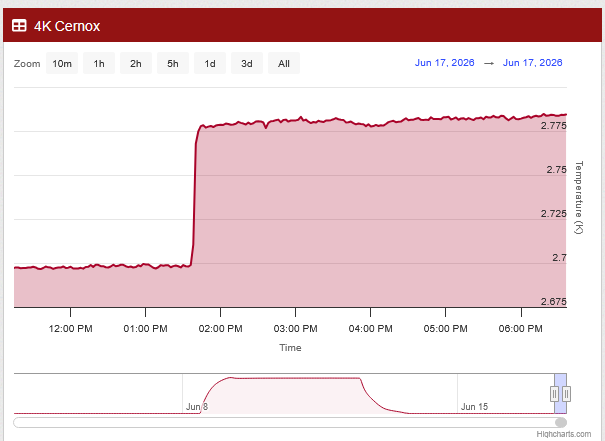

In [55]:
params.args(params.critical_current)

(device, dmm=None, yoko=None, tc=None, unlatch=True, station=None)


In [61]:
pos_currents = [-i for i in params.device_line_2['currents']]
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc, currents=pos_currents)

update station
Ramping to 0
Unlatch wait time 60
Ramping to -0.0
Starting experimental run with id: 31. 
31


  0%|                                                                                                  | 0/53 [00:00<?, ?it/s]

Starting current -0.0


  2%|█▋                                                                                        | 1/53 [00:14<12:13, 14.10s/it]

Starting current 2.5e-07


...

Starting current 1.275e-05


 98%|███████████████████████████████████████████████████████████████████████████████████████▎ | 52/53 [11:53<00:12, 12.58s/it]

Starting current 1.3e-05


100%|█████████████████████████████████████████████████████████████████████████████████████████| 53/53 [12:07<00:00, 13.72s/it]


Ramping to 0
Unlatch wait time 60


June 18
To do:
1. Lower amplifier power current sweep
2. Turn off amplifiers. Wait for power to go down, then sweep positive currents again. Or in the meantime of 1. look for the old trace with positive currents.
3. \4K amplifier power supply set to 1V output, reading 0.01A. 11:53am.

In [62]:
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc, currents=pos_currents, unlatch=False)

update station
Ramping to -0.0
Starting experimental run with id: 32. 
32


  0%|                                                                                           | 0/53 [00:00<?, ?it/s]

Starting current -0.0


  2%|█▌                                                                                 | 1/53 [00:14<12:14, 14.12s/it]

Starting current 2.5e-07


...

 96%|██████████████████████████████████████████████████████████████████████████████▉   | 51/53 [11:44<00:26, 13.22s/it]

Starting current 1.275e-05


 98%|████████████████████████████████████████████████████████████████████████████████▍ | 52/53 [11:58<00:13, 13.49s/it]

Starting current 1.3e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 53/53 [12:12<00:00, 13.83s/it]


Amplifier on at low power, sweeping positive currents. 

In [71]:
step = np.diff(params.device_line_2['currents'])[0]
currents = np.arange(0, -20e-6, step)
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc, currents=currents, unlatch=False)

update station
Ramping to 0.0
Starting experimental run with id: 33. 
33


  0%|                                                                                           | 0/81 [00:00<?, ?it/s]

Starting current 0.0


  1%|█                                                                                  | 1/81 [00:12<17:03, 12.79s/it]

Starting current -2.5e-07


...

 98%|███████████████████████████████████████████████████████████████████████████████▉  | 79/81 [18:12<00:27, 13.89s/it]

Starting current -1.975e-05


 99%|████████████████████████████████████████████████████████████████████████████████▉ | 80/81 [18:27<00:13, 13.96s/it]

Starting current -2e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 81/81 [18:38<00:00, 13.80s/it]


In [72]:
step = np.diff(params.device_line_2['currents'])[0]
pos_currents = np.arange(0, 20e-6, -step)
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc, currents=pos_currents)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 34. 
34


  0%|                                                                                                  | 0/81 [00:00<?, ?it/s]

Starting current 0.0


  1%|█                                                                                         | 1/81 [00:14<18:47, 14.09s/it]

Starting current 2.5e-07


...

Starting current 1.975e-05


 99%|███████████████████████████████████████████████████████████████████████████████████████▉ | 80/81 [18:35<00:14, 14.13s/it]

Starting current 2e-05


100%|█████████████████████████████████████████████████████████████████████████████████████████| 81/81 [18:49<00:00, 13.94s/it]


Ramping to 0
Unlatch wait time 60


In [73]:
params.unlatch(yoko)

Ramping to 0
Unlatch wait time 60


Positive and negative currents sweep again with amplifiers off. 

In [74]:
pos_currents = [-i for i in params.device_line_2['currents']]
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc, currents=pos_currents)

update station
Ramping to 0
Unlatch wait time 60
Ramping to -0.0
Starting experimental run with id: 35. 
35


  0%|                                                                                           | 0/53 [00:00<?, ?it/s]

Starting current -0.0


  2%|█▌                                                                                 | 1/53 [00:14<12:13, 14.10s/it]

Starting current 2.5e-07


...

Starting current 1.275e-05


 98%|████████████████████████████████████████████████████████████████████████████████▍ | 52/53 [12:08<00:14, 14.12s/it]

Starting current 1.3e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 53/53 [12:22<00:00, 14.01s/it]


Ramping to 0
Unlatch wait time 60


In [75]:
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc, currents=pos_currents)

update station
Ramping to 0
Unlatch wait time 60
Ramping to -0.0
Starting experimental run with id: 36. 
36


  0%|                                                                                           | 0/53 [00:00<?, ?it/s]

Starting current -0.0


  2%|█▌                                                                                 | 1/53 [00:14<12:12, 14.10s/it]

Starting current 2.5e-07


...

Starting current 1.275e-05


 98%|████████████████████████████████████████████████████████████████████████████████▍ | 52/53 [12:03<00:13, 13.47s/it]

Starting current 1.3e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 53/53 [12:14<00:00, 13.86s/it]


Ramping to 0
Unlatch wait time 60


Accidentally set ID36 to run positive currents again. But also, both devices did not transition. Repeat positive sweep for a wider range. It could be that it has an offset

In [7]:
step = np.diff(params.device_line_2['currents'])[0]
pos_currents = np.arange(0, 20e-6, -step)
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc, currents=pos_currents)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 38. 
38


  0%|                                                                                           | 0/81 [00:00<?, ?it/s]

Starting current 0.0


  1%|█                                                                                  | 1/81 [00:14<18:47, 14.10s/it]

Starting current 2.5e-07


...

Starting current 1.975e-05


 99%|████████████████████████████████████████████████████████████████████████████████▉ | 80/81 [18:37<00:14, 14.06s/it]

Starting current 2e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 81/81 [18:51<00:00, 13.97s/it]


Ramping to 0
Unlatch wait time 60


In [8]:
step = np.diff(params.device_line_2['currents'])[0]
neg_currents = np.arange(0, -20e-6, step)
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc, currents=neg_currents)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 39. 
39


  0%|                                                                                           | 0/81 [00:00<?, ?it/s]

Starting current 0.0


  1%|█                                                                                  | 1/81 [00:14<18:47, 14.10s/it]

Starting current -2.5e-07


...

Starting current -1.975e-05


 99%|████████████████████████████████████████████████████████████████████████████████▉ | 80/81 [18:25<00:14, 14.11s/it]

Starting current -2e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 81/81 [18:39<00:00, 13.82s/it]


Ramping to 0
Unlatch wait time 60


Note that I have just discovered for ID35-39 the 4K power supply was off, but the room temperature ampifier power supply is on. Repeat positive and negative current sweeps with other power supply off. 

In [9]:
step = np.diff(params.device_line_2['currents'])[0]
pos_currents = np.arange(0, 20e-6, -step)
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc, currents=pos_currents)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 40. 
40


  0%|                                                                                           | 0/81 [00:00<?, ?it/s]

Starting current 0.0


  1%|█                                                                                  | 1/81 [00:14<18:48, 14.11s/it]

Starting current 2.5e-07


...

Starting current 1.975e-05


 99%|████████████████████████████████████████████████████████████████████████████████▉ | 80/81 [18:35<00:14, 14.12s/it]

Starting current 2e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 81/81 [18:49<00:00, 13.95s/it]


Ramping to 0
Unlatch wait time 60


In [10]:
step = np.diff(params.device_line_2['currents'])[0]
neg_currents = np.arange(0, -20e-6, step)
params.critical_current(device=params.device_line_2, yoko=yoko, dmm=dmm, tc=tc, currents=neg_currents)

update station
Ramping to 0
Unlatch wait time 60
Ramping to 0.0
Starting experimental run with id: 41. 
41


  0%|                                                                                                  | 0/81 [00:00<?, ?it/s]

Starting current 0.0


  1%|█                                                                                         | 1/81 [00:14<18:48, 14.10s/it]

Starting current -2.5e-07


...

Starting current -1.975e-05


 99%|███████████████████████████████████████████████████████████████████████████████████████▉ | 80/81 [18:29<00:14, 14.12s/it]

Starting current -2e-05


100%|█████████████████████████████████████████████████████████████████████████████████████████| 81/81 [18:43<00:00, 13.87s/it]


Ramping to 0
Unlatch wait time 60


19/6
Objectives  

* Measure critical current with 1MOhm bias resistor (applying voltage) with both amplifiers on (4K amplifier power supply set to 2.5) 

* Capture traces with 1MOhm bias resistor (applying voltage) with both amplifiers on (4K amplifier power supply set to 2.5) 

* Measure critical current with 1MOhm bias resistor (applying voltage) with both amplifiers off


Observation: when amplifier power supply was turned on (1.1V), and voltage source swept, the peak was very small and almost indistinguishable. 

In [12]:
np.diff(params.device_line_2['currents'])

array([-2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07,
       -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07,
       -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07,
       -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07,
       -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07,
       -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07,
       -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07,
       -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07,
       -2.5e-07, -2.5e-07, -2.5e-07, -2.5e-07])

In [43]:
# Calculating power dissipated in resistor 
vrange = np.arange(0, -14, -0.2)
Rb = 1e6 
P = vrange**2/Rb
print(f'Power: {P*1e3}mW')

# check 
I = 13e-6
P = I**2*Rb
print(f'{I*1e6}uA gives Power: {P*1e3:.3f}mW')

Power: [0.0000e+00 4.0000e-05 1.6000e-04 3.6000e-04 6.4000e-04 1.0000e-03
 1.4400e-03 1.9600e-03 2.5600e-03 3.2400e-03 4.0000e-03 4.8400e-03
 5.7600e-03 6.7600e-03 7.8400e-03 9.0000e-03 1.0240e-02 1.1560e-02
 1.2960e-02 1.4440e-02 1.6000e-02 1.7640e-02 1.9360e-02 2.1160e-02
 2.3040e-02 2.5000e-02 2.7040e-02 2.9160e-02 3.1360e-02 3.3640e-02
 3.6000e-02 3.8440e-02 4.0960e-02 4.3560e-02 4.6240e-02 4.9000e-02
 5.1840e-02 5.4760e-02 5.7760e-02 6.0840e-02 6.4000e-02 6.7240e-02
 7.0560e-02 7.3960e-02 7.7440e-02 8.1000e-02 8.4640e-02 8.8360e-02
 9.2160e-02 9.6040e-02 1.0000e-01 1.0404e-01 1.0816e-01 1.1236e-01
 1.1664e-01 1.2100e-01 1.2544e-01 1.2996e-01 1.3456e-01 1.3924e-01
 1.4400e-01 1.4884e-01 1.5376e-01 1.5876e-01 1.6384e-01 1.6900e-01
 1.7424e-01 1.7956e-01 1.8496e-01 1.9044e-01]mW
13.0uA gives Power: 0.169mW


In [21]:
meas = Measurement()
meas.register_parameter(yoko.voltage)

In [8]:
def critical_current_setv(params, device, Rb, dmm=None, yoko=None, voltages=None, station=None):
        # Note: tc was removed from this function because of an IT issue
    
        import tqdm

        if yoko.source_mode() != 'VOLT': 
            raise Exception('Yoko is not in voltage mode')
        
        # Read from station internally unless an instrument is passed 
        yoko = params.yoko if yoko is None else yoko
        dmm = params.dmm if dmm is None else dmm 
        # tc = params.tc if tc is None else tc 

        # Update station
        params.update_station(station)

        # Establish measurement
        meas = Measurement()
        meas.register_parameter(yoko.voltage)
        meas.register_parameter(dmm.volt, setpoints=(yoko.voltage,))
        # meas.register_custom_parameter("MC_temp", label="K")
        meas.register_custom_parameter("Rbias", label="Ohms")

        # Set first current 
        if yoko.voltage() != voltages[0]: 
            raise Exception('Ramp to first voltage value')
       

        with meas.run() as datasaver:
            print(datasaver.run_id)
            
            # save device name 
            datasaver.dataset.add_metadata("device", device['name'])


            for v in tqdm.tqdm(voltages): 

                # set current 
                yoko.voltage(v)
                time.sleep(1)
                print(f'Starting voltage {yoko.voltage()}')

                # Save data 
                datasaver.add_result((yoko.voltage, yoko.voltage()),
                                    (dmm.volt, dmm.volt()),
                                    # ("MC_temp", tc.MC_temp()),
                                    ("Rbias", Rb))
                
                time.sleep(10)
        
        # Ramp to zero and wait 
        print('Unlatch, ramp to zero and wait') 
        for v in voltages[::-1]: 
            yoko.voltage(v)
            time.sleep(1)
        time.sleep(30)
        

ID 48: Measure critical current with 1MOhm bias resistor (applying voltage) with both amplifiers on (4K amplifier power supply set to 2.5). Temperature omitted from measurement due to server issue happening with uni IT at the moment. 

In [44]:
yoko.voltage_range(30)

In [64]:
vrange = np.arange(0, -14, -0.25)
yoko.output('off')
yoko.source_mode('VOLT')
yoko.output('on')
Rb=1.015e6

critical_current_setv(params, params.device_line_2, Rb, dmm, yoko, voltages=vrange, station=station)

update station
Starting experimental run with id: 48. 
48


  0%|                                                                                           | 0/56 [00:00<?, ?it/s]

Starting voltage 0.0


  2%|█▍                                                                                 | 1/56 [00:11<10:08, 11.06s/it]

Starting voltage -0.25


...

Starting voltage -13.5


 98%|████████████████████████████████████████████████████████████████████████████████▌ | 55/56 [10:09<00:11, 11.09s/it]

Starting voltage -13.75


100%|██████████████████████████████████████████████████████████████████████████████████| 56/56 [10:20<00:00, 11.09s/it]


Unlatch, ramp to zero and wait


Amplifiers off, give time for temperature to decrease. 

ID 49: Measure critical current with 1MOhm bias resistor (applying voltage) with both amplifiers off. 
Increased to 16V to allow for resistance to be obvious

In [66]:
vrange = np.arange(0, -16, -0.25)
yoko.output('off')
yoko.source_mode('VOLT')
yoko.output('on')
Rb=1.015e6

critical_current_setv(params, params.device_line_2, Rb, dmm, yoko, voltages=vrange, station=station)

update station
Starting experimental run with id: 49. 
49


  0%|                                                                                           | 0/64 [00:00<?, ?it/s]

Starting voltage 0.0


  2%|█▎                                                                                 | 1/64 [00:11<11:36, 11.06s/it]

Starting voltage -0.25


...

Starting voltage -15.5


 98%|████████████████████████████████████████████████████████████████████████████████▋ | 63/64 [11:38<00:11, 11.09s/it]

Starting voltage -15.75


100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [11:49<00:00, 11.09s/it]


Unlatch, ramp to zero and wait


ID 50: Re-do measure critical current with 1MOhm bias resistor (applying voltage) with both amplifiers on (4K amplifier power supply set to 2.5), wider range to 16V. Temperature omitted from measurement due to server issue happening with uni IT at the moment. 

In [67]:
vrange = np.arange(0, -16, -0.25)
yoko.output('off')
yoko.source_mode('VOLT')
yoko.output('on')
Rb=1.015e6

critical_current_setv(params, params.device_line_2, Rb, dmm, yoko, voltages=vrange, station=station)

update station
Starting experimental run with id: 50. 
50


  0%|                                                                                           | 0/64 [00:00<?, ?it/s]

Starting voltage 0.0


  2%|█▎                                                                                 | 1/64 [00:11<11:36, 11.06s/it]

Starting voltage -0.25


...

Starting voltage -15.5


 98%|████████████████████████████████████████████████████████████████████████████████▋ | 63/64 [11:38<00:11, 11.08s/it]

Starting voltage -15.75


100%|██████████████████████████████████████████████████████████████████████████████████| 64/64 [11:49<00:00, 11.09s/it]


Unlatch, ramp to zero and wait


In [78]:
def trace_vs_voltage(params, device, Rbias, voltages, MS, dmm, yoko, p_att, trigger, v_scale, wait=120, station=None):
    ''' Parameters 
    '''
    import tqdm
    # for each segment of data
    if yoko.source_mode() != 'VOLT': 
        raise Exception('Yoko is not in voltage mode')
        
    # Set first current 
    if yoko.voltage() != voltages[0]: 
        raise Exception('Ramp to first voltage value')

    # Update experiment snapshot 
    params.update_station(station)
    
    meas = Measurement()
    meas.register_custom_parameter("time_axis", label="time_axis")
    meas.register_custom_parameter("trace", label="trace", setpoints=("time_axis", ))
    meas.register_custom_parameter("h_samples", label="samples")
    meas.register_custom_parameter("h_centre", label="samples")
    meas.register_custom_parameter("h_samplerate", label="samples/sec")
    meas.register_custom_parameter("h_position_perc", label="samples")
    meas.register_parameter(dmm.volt)
    meas.register_parameter(yoko.voltage) # minimise number of things required in a global namespace 
    meas.register_custom_parameter("v_attenuator", label="V")
    meas.register_custom_parameter('trigger', label='V')
    meas.register_custom_parameter('v_scale', label='V')
    meas.register_custom_parameter('v_peak', label='V')
    meas.register_custom_parameter('Rbias', label='Ohms')
    
    with meas.run() as datasaver:
        print(datasaver.run_id)

        for (idx, v) in tqdm.tqdm(enumerate(voltages)): 
            yoko.voltage(v)
            
            datasaver.dataset.add_metadata("device", device['name'])
            
            waveform, h_samples, h_samplerate, h_position_perc, h_centre, time_axis, trigger, v_scale, v_peak = params.capture_trace(MS, trigger, v_scale, wait)

            datasaver.add_result(("trace", waveform),
                        ("time_axis", time_axis),
                        (yoko.voltage, yoko.voltage()), 
                        ("h_samplerate", h_samplerate), 
                        ("h_samples", h_samples),
                        ("h_position_perc", h_position_perc),
                        ("h_centre", h_centre),
                        (dmm.volt, dmm.volt()),
                        ('v_attenuator', float(p_att.ask('VOLT?'))),
                        ('trigger',  MS.trigger_channels[0].ch1_trigger_level()),
                        ("v_scale", float(MS.channels[0].vertical_scale())),
                        ('v_peak', v_peak),
                        ('Rbias', Rbias))
        
    # Ramp to zero and wait 
    print('Unlatch, ramp to zero and wait') 
    for v in voltages[::-1]: 
        yoko.voltage(v)
        time.sleep(1)
    time.sleep(30)

In [73]:
np.arange(0, -17, -0.25)[::4]

array([  0.,  -1.,  -2.,  -3.,  -4.,  -5.,  -6.,  -7.,  -8.,  -9., -10.,
       -11., -12., -13., -14., -15., -16.])

ID53: Capture traces with 1MOhm bias resistor (applying voltage) with both amplifiers on (4K amplifier power supply set to 2.5) 

In [81]:
voltages = np.arange(0, -16, -0.25)[::4] # integer values only
yoko.output('off')
yoko.source_mode('VOLT')
yoko.output('on')
Rbias=1.015e6

trace_vs_voltage(params, params.device_line_2, Rbias, voltages, MS, dmm, yoko, p_att, trigger=18e-3, v_scale=50e-3, wait=120, station=None)

update station
Starting experimental run with id: 53. 
53


0it [00:00, ?it/s]

Oscilloscope set for trace capture
0.05
update station
Acquisition took 120.13 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 12.8V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";2.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


1it [02:17, 137.30s/it]

Oscilloscope set for trace capture
0.05
update station
Acquisition took 120.10 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 12.8V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";2.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


...

Oscilloscope set for trace capture
0.05
update station
Acquisition took 120.12 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 12.8V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";2.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


15it [08:24, 47.14s/it]

Oscilloscope set for trace capture
0.05
update station
Acquisition took 120.14 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 12.8V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";2.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


16it [10:42, 40.13s/it]


Unlatch, ramp to zero and wait


June 22 10:21am

Objectives 
* Result to compare to ID13: no amplifiers, no laser. The MXC thermometer currently reasds 14.63 mK which is lower than the ID13 reading of 48.63. Perform the sweep now to look at the impact of temperature.


In [82]:
laser.enable()

False

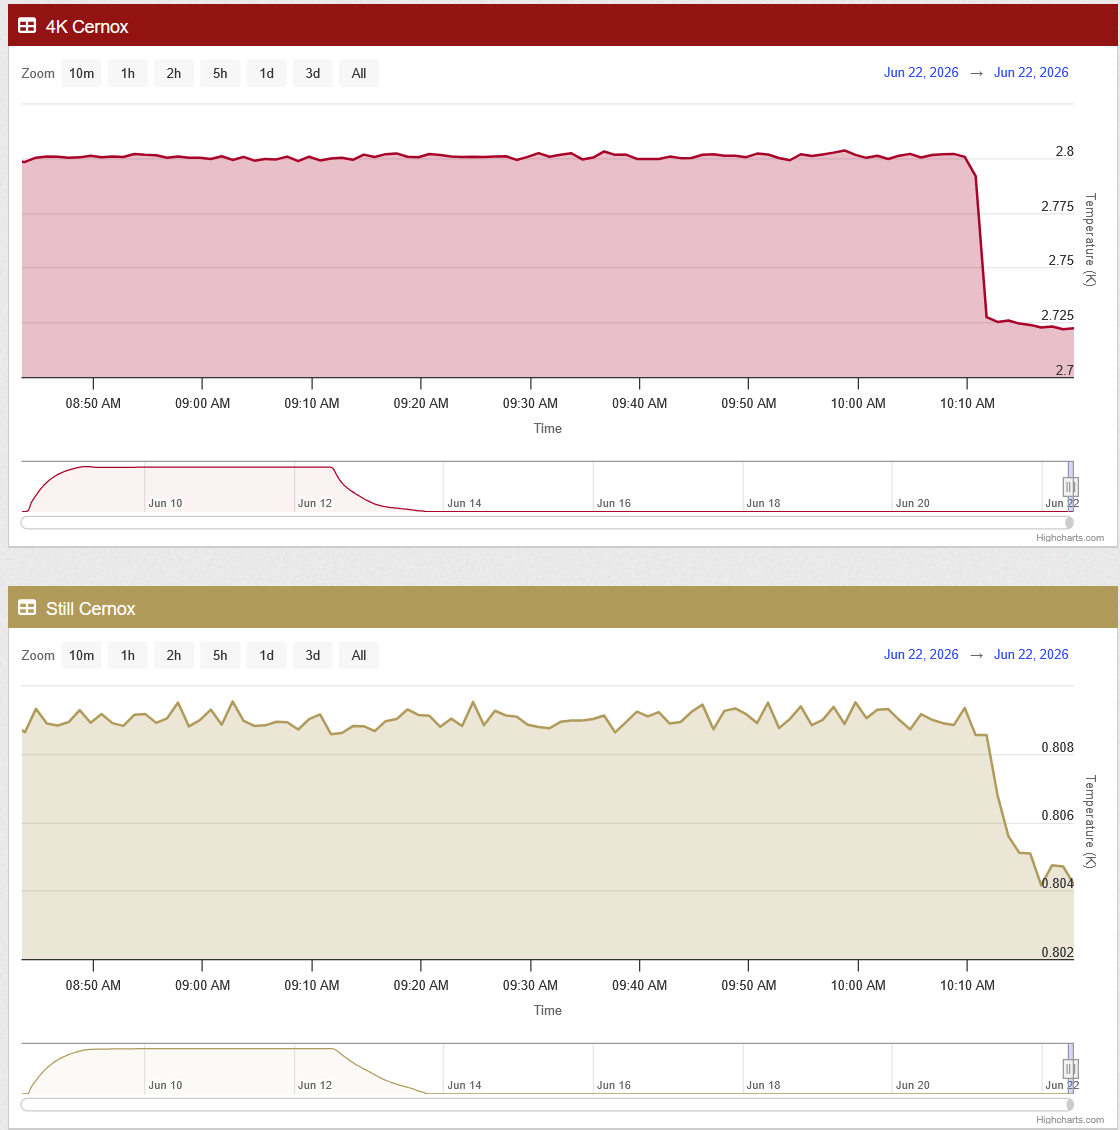

In [83]:
# Allow time for temperature to settle 
time.sleep(60*5)

Writing critical current function to eliminate the need for the fridge thermometry due to IT error - current MXC reading (10:24am is 14.730mK). 

In [6]:
def critical_current_no_tc(params, device, yoko, dmm, MC_temp_manual, currents=None, unlatch=True, station=None):
    import tqdm
    '''
    interval is specified in seconds
    unlatch: bool, if true the function will include unlatch code
    '''
    # Read from station internally unless an instrument is passed 
    yoko = self.yoko if yoko is None else yoko
    dmm = self.dmm if dmm is None else dmm 
    # tc = self.tc if tc is None else tc 
    currents = device['currents'] if currents is None else currents

    device_name = device['name']

    # Update station
    params.update_station(station)

    # Establish measurement
    meas = Measurement()
    meas.register_parameter(yoko.current)
    meas.register_parameter(dmm.volt, setpoints=(yoko.current,))
    meas.register_custom_parameter("MC_temp", label="K")

    # Ramp to zero and wait 
    if unlatch:
        params.unlatch(yoko)

    # Set first current 
    params.ramp_yoko_current(yoko, target=currents[0], step=0.5e-6) 
    yoko.current(currents[0])
   

    with meas.run() as datasaver:
        print(datasaver.run_id)
        
        # save device name 
        datasaver.dataset.add_metadata("device", device_name)


        for cur in tqdm.tqdm(currents): # <- sweep wavelength of laser 

            # set current 
            yoko.current(cur)
            time.sleep(1)
            print(f'Starting current {yoko.current()}')

            
            # Save data 
            datasaver.add_result((yoko.current, yoko.current()),
                                (dmm.volt, dmm.volt()),
                                ("MC_temp", MC_temp_manual))
            
            time.sleep(10)
    
    # Ramp to zero and wait 
    params.unlatch(yoko)

ID 55:comparison to ID13, critical current sweep at lower temperature, laser and amplifiers off

In [107]:
critical_current_no_tc(params, params.device_line_2, yoko, dmm, MC_temp_manual=14.730e-3, unlatch=False, station=station)

update station
Ramping to 0.0
Starting experimental run with id: 55. 
55


  0%|                                                                                           | 0/53 [00:00<?, ?it/s]

Starting current 0.0


  2%|█▌                                                                                 | 1/53 [00:11<09:34, 11.06s/it]

Starting current -2.5e-07


...

Starting current -1.275e-05


 98%|████████████████████████████████████████████████████████████████████████████████▍ | 52/53 [09:36<00:11, 11.08s/it]

Starting current -1.3e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 53/53 [09:47<00:00, 11.08s/it]


Ramping to 0
Unlatch wait time 60


No transition. Widening voltage range to capture transition. 

ID 56: comparison to ID13, critical current sweep at lower temperature, laser and amplifiers off

In [110]:
step = np.diff(params.device_line_2['currents'])[0]
currents = np.arange(0, -20e-6, step)
critical_current_no_tc(params, params.device_line_2, yoko, dmm, currents=currents, MC_temp_manual=14.774e-3, unlatch=False, station=station)

update station
Ramping to 0.0
Starting experimental run with id: 56. 
56


  0%|                                                                                           | 0/81 [00:00<?, ?it/s]

Starting current 0.0


  1%|█                                                                                  | 1/81 [00:11<14:45, 11.07s/it]

Starting current -2.5e-07


...

Starting current -1.975e-05


 99%|████████████████████████████████████████████████████████████████████████████████▉ | 80/81 [14:46<00:11, 11.08s/it]

Starting current -2e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 81/81 [14:57<00:00, 11.08s/it]


Ramping to 0
Unlatch wait time 60


In [111]:
laser.enable()

False

ID57: Trying laser on again to see if at lower temperature, the laser being on alters the transition current. 

In [112]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

Laser enable status: True


In [113]:
step = np.diff(params.device_line_2['currents'])[0]
currents = np.arange(0, -20e-6, step)
critical_current_no_tc(params, params.device_line_2, yoko, dmm, currents=currents, MC_temp_manual=14.774e-3, unlatch=False, station=station)

update station
Ramping to 0.0
Starting experimental run with id: 57. 
57


  0%|                                                                                           | 0/81 [00:00<?, ?it/s]

Starting current 0.0


  1%|█                                                                                  | 1/81 [00:11<14:44, 11.06s/it]

Starting current -2.5e-07


...

Starting current -1.975e-05


 99%|████████████████████████████████████████████████████████████████████████████████▉ | 80/81 [14:47<00:11, 11.08s/it]

Starting current -2e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 81/81 [14:58<00:00, 11.09s/it]


Ramping to 0
Unlatch wait time 60


In [114]:
laser.enable()

True

In [115]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Note that at the end of this sweep the mixing chamber reads 14.783mK (small increase)

ID58: Trying amplifiers on again to see if at lower temperature, the amplifiers being on alters the transition current. (normal setings 5V for RT and 2.5V for 4K)

In [4]:
time.sleep(5*60)

In [7]:
step = np.diff(params.device_line_2['currents'])[0]
currents = np.arange(0, -20e-6, step)
critical_current_no_tc(params, params.device_line_2, yoko, dmm, currents=currents, MC_temp_manual=14.754e-3, unlatch=False, station=station)

update station
Ramping to 0.0
Starting experimental run with id: 58. 
58


  0%|                                                                                           | 0/81 [00:00<?, ?it/s]

Starting current 0.0


  1%|█                                                                                  | 1/81 [00:11<14:45, 11.06s/it]

Starting current -2.5e-07


...

Starting current -1.975e-05


 99%|████████████████████████████████████████████████████████████████████████████████▉ | 80/81 [14:46<00:11, 11.09s/it]

Starting current -2e-05


100%|██████████████████████████████████████████████████████████████████████████████████| 81/81 [14:57<00:00, 11.08s/it]


Ramping to 0
Unlatch wait time 60


Reading after sweep is 14.538mK (also after lunch, 1:12pm)

ID59: Then maybe swap the bias method one more time and run the sweep at similar temperature again to try to rule out the effect of temperature. 
0.01mA drawn with 0V applied with yoko (on voltage mode) output ON but zero volt. 

In [10]:
yoko.output('off')

In [11]:
yoko.source_mode('VOLT')

In [12]:
yoko.output('on')

In [13]:
# Turn amplifiers off and wait 10min for temp to definitely go down
time.sleep(600)

In [ ]:
vrange = np.arange(0, -20, -0.25)
yoko.output('off')
yoko.source_mode('VOLT')
yoko.output('on')
Rb=1.015e6
# Tc beginning of sweep is 14.604mK
critical_current_setv(params, params.device_line_2, Rb, dmm, yoko, voltages=vrange, station=station)

update station
Starting experimental run with id: 59. 
59


  0%|                                                                                           | 0/80 [00:00<?, ?it/s]

Starting voltage 0.0


  1%|█                                                                                  | 1/80 [00:11<14:33, 11.06s/it]

Starting voltage -0.25


...

Starting voltage -10.25


 52%|███████████████████████████████████████████                                       | 42/80 [07:45<07:01, 11.09s/it]

Starting voltage -10.5


 54%|████████████████████████████████████████████                                      | 43/80 [07:56<06:50, 11.09s/it]

Starting voltage -10.75


Observed MXC temp went up to 14.718 at starting voltage -1.75